# Customer Behavior EDA

Objective: Analyze customer ordering cadence, reorder intensity, and basket behavior.

In [15]:
import importlib
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Setup project path
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists() and (parent / "data").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Reload the loader module so notebook execution always uses the latest code.
import instacart_quality.data_access as data_access_module
importlib.reload(data_access_module)

USE_SAMPLE = True
df = data_access_module.load_customer_behavior_data(
    use_sample=USE_SAMPLE,
    project_root=PROJECT_ROOT,
)

print(f"Loaded {len(df):,} records with {df['user_id'].nunique():,} unique customers")
print(f"Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f"Columns: {list(df.columns)}\n")
df.head()

Loaded 778,814 records with 30 unique customers
Date range: 2015-06-01 to 2015-07-01
Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'cumulative_days', 'order_date', 'product_name', 'total_price', 'cumulative_reorder_per_customer']



,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,cumulative_days,order_date,product_name,total_price,cumulative_reorder_per_customer
0,112819,5646,1,1,21085.0,prior,3.0,3.0,8.0,23.0,23.0,2015-06-08,Organic Turkey Bacon,1,1.0
1,112819,32857,2,1,21085.0,prior,3.0,3.0,8.0,23.0,23.0,2015-06-08,Organic Chunky Tomato Bisque Soup,1,2.0
2,1993829,42445,1,1,23798.0,prior,4.0,0.0,16.0,6.0,6.0,2015-06-25,Organic Plain Whole Milk Yogurt,1,1.0
3,1993829,41177,2,1,23798.0,prior,4.0,0.0,16.0,6.0,6.0,2015-06-25,Sea Salt Roasted Seaweed,1,2.0
4,1993829,32655,3,1,23798.0,prior,4.0,0.0,16.0,6.0,6.0,2015-06-25,Organic Large Grade AA Brown Eggs,1,3.0


## Analysis Questions
- Do customers who reorder have shorter days between orders?
- Do high-order-history customers reorder more?
- How strongly does cumulative reorder history separate behavior groups?

In [16]:
customer_kpi = (
    df.groupby("user_id")
    .agg(
        total_orders=("order_number", "max"),
        total_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
        avg_days_between_orders=("days_since_prior_order", "mean"),
        cumulative_reorder_last=("cumulative_reorder_per_customer", "max"),
    )
    .reset_index()
)

display(customer_kpi.describe(include="all"))

summary_by_reordered = (
    df.groupby("reordered")
    .agg(
        avg_days_since_prior_order=("days_since_prior_order", "mean"),
        median_order_number=("order_number", "median"),
        median_cumulative_reorder=("cumulative_reorder_per_customer", "median"),
        sample_size=("order_id", "count"),
    )
)
summary_by_reordered

,user_id,total_orders,total_lines,reorder_rate,avg_days_between_orders,cumulative_reorder_last
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,112445.533333,11.300000,10.800000,0.576723,11.466667,5.733333
std,53722.903126,10.120481,8.856714,0.272807,9.637332,4.755638
min,21085.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,65859.500000,4.000000,5.000000,0.388462,5.000000,2.250000
50%,112041.000000,9.000000,8.500000,0.591667,7.000000,4.000000
75%,149459.500000,15.000000,16.000000,0.755348,16.000000,8.000000
max,201853.000000,46.000000,33.000000,1.000000,30.000000,18.000000


,avg_days_since_prior_order,median_order_number,median_cumulative_reorder,sample_size
reordered,,,,
0,14.348684,4.0,4.5,322439
1,10.779070,10.0,4.0,456375


## Bivariate Comparison

This section was moved from the overview notebook and consolidated here for customer behavior interpretation.

## - Reorder Behavior

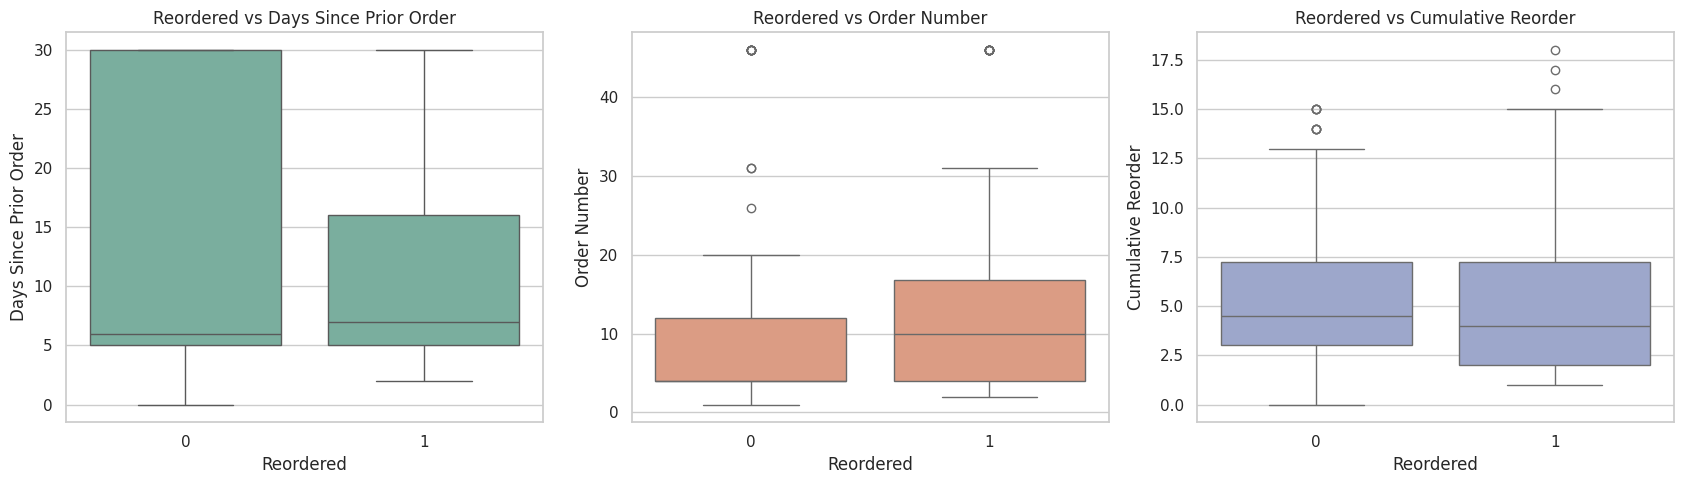

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.boxplot(x="reordered", y="days_since_prior_order", data=df, ax=axes[0], color="#72B6A1")
axes[0].set_title("Reordered vs Days Since Prior Order")
axes[0].set_xlabel("Reordered")
axes[0].set_ylabel("Days Since Prior Order")

sns.boxplot(x="reordered", y="order_number", data=df, ax=axes[1], color="#E99675")
axes[1].set_title("Reordered vs Order Number")
axes[1].set_xlabel("Reordered")
axes[1].set_ylabel("Order Number")

sns.boxplot(x="reordered", y="cumulative_reorder_per_customer", data=df, ax=axes[2], color="#95A3D3")
axes[2].set_title("Reordered vs Cumulative Reorder")
axes[2].set_xlabel("Reordered")
axes[2].set_ylabel("Cumulative Reorder")

plt.tight_layout()
plt.show()

In [18]:
# Compare metrics between reordered and non-reordered items
reordered_yes = df[df["reordered"] == 1]
reordered_no = df[df["reordered"] == 0]

comparison_stats = {
    "days_since_prior_order": reordered_yes["days_since_prior_order"].mean() - reordered_no["days_since_prior_order"].mean(),
    "order_number": reordered_yes["order_number"].median() - reordered_no["order_number"].median(),
    "cumulative_reorder": reordered_yes["cumulative_reorder_per_customer"].median() - reordered_no["cumulative_reorder_per_customer"].median(),
}

pd.Series(comparison_stats, name="difference").to_frame()

,difference
days_since_prior_order,-3.569614
order_number,6.000000
cumulative_reorder,-0.500000


## Key Insight Notes
- If days_since_prior_order difference is negative, reordered users tend to come back sooner.
- Positive median order_number difference indicates reorders increase with customer order history.
- Positive cumulative_reorder median difference indicates reorder behavior is reinforced over time.

## - Order & Reorder Behavior / Day time 

In [19]:
order_level = (
    df.groupby("order_id")
    .agg(
        order_dow=("order_dow", "first"),
        order_hour_of_day=("order_hour_of_day", "first"),
        total_products=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
        days_since_prior_order=("days_since_prior_order", "first"),
    )
    .reset_index()
)

print("Order-Level Summary:")
display(order_level.drop(columns=["order_id"]).describe(include="all"))

Order-Level Summary:


,order_dow,order_hour_of_day,total_products,reorder_rate,days_since_prior_order
count,30.000000,30.000000,77862.000000,77862.000000,30.000000
mean,2.033333,13.566667,10.002492,0.598993,11.466667
std,2.025413,3.339248,7.328063,0.338751,9.637332
min,0.000000,8.000000,1.000000,0.000000,0.000000
25%,0.000000,11.250000,5.000000,0.333333,5.000000
50%,1.000000,14.000000,8.000000,0.666667,7.000000
75%,4.000000,15.750000,14.000000,0.909091,16.000000
max,6.000000,20.000000,70.000000,1.000000,30.000000


In [20]:
day_map = {
    0: "Sun", 1: "Mon", 2: "Tue",
    3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"
}

order_level["day_name"] = order_level["order_dow"].map(day_map)
order_level["day_name"] = pd.Categorical(
    order_level["day_name"],
    categories=["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"],
    ordered=True
)

customer_kpi = (
    order_level.groupby(["day_name", "order_hour_of_day"], observed=False)
    .agg(
        avg_orders=("order_id", "count"),
        avg_products_per_order=("total_products", "mean"),
        avg_reorder_rate=("reorder_rate", "mean"),
        avg_days_between_orders=("days_since_prior_order", "mean"),
    )
    .reset_index()
    .sort_values(["day_name", "order_hour_of_day"])
)

print("Order-Customer KPI Summary:")
display(customer_kpi.describe(include="all"))

Order-Customer KPI Summary:


,day_name,order_hour_of_day,avg_orders,avg_products_per_order,avg_reorder_rate,avg_days_between_orders
count,84,84.000000,84.000000,26.000000,26.000000,26.000000
unique,7,NaN,NaN,NaN,NaN,NaN
top,Sun,NaN,NaN,NaN,NaN,NaN
freq,12,NaN,NaN,NaN,NaN,NaN
mean,NaN,13.666667,0.357143,10.557692,0.583739,11.673077
std,NaN,3.726600,0.573362,8.803780,0.287752,9.503623
min,NaN,8.000000,0.000000,1.000000,0.000000,0.000000
25%,NaN,10.750000,0.000000,4.250000,0.368077,5.000000
50%,NaN,13.500000,0.000000,8.250000,0.600000,7.500000
75%,NaN,16.250000,1.000000,15.625000,0.755348,16.000000


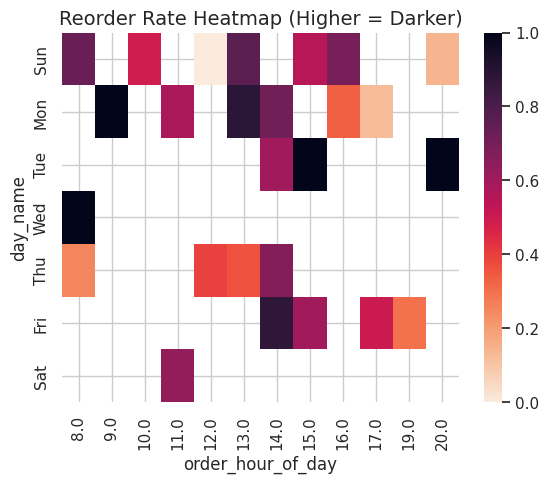

In [21]:
pivot = customer_kpi.pivot(
    index="day_name",
    columns="order_hour_of_day",
    values="avg_reorder_rate"
)

sns.heatmap(pivot, cmap="rocket_r")
plt.title("Reorder Rate Heatmap (Higher = Darker)", fontsize=14)
plt.show()

<Axes: xlabel='order_hour_of_day', ylabel='avg_reorder_rate'>

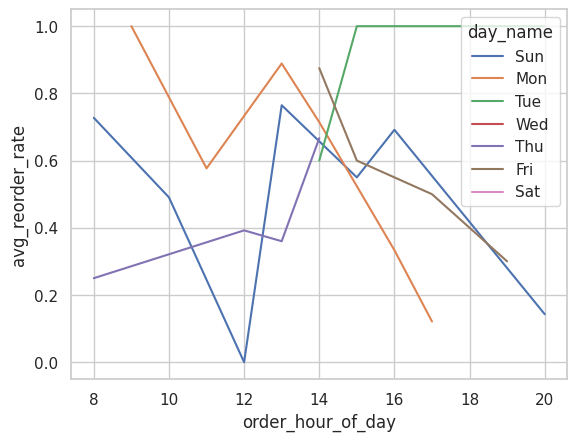

In [22]:
sns.lineplot(
    data=customer_kpi,
    x="order_hour_of_day",
    y="avg_reorder_rate",
    hue="day_name"
    )

<Axes: xlabel='day_name', ylabel='reorder_rate'>

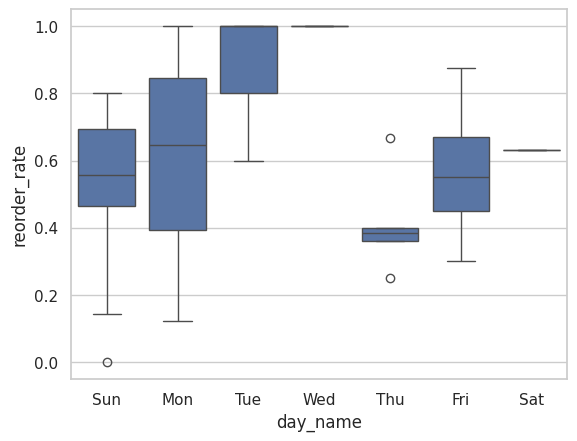

In [23]:
sns.boxplot(
    data=order_level,
    x="day_name",
    y="reorder_rate"
    )

## Segmentation Analysis

### 1 . Customer segmentation (RFM, cohort groups)

การแบ่งกลุ่มลูกค้า

RFM = Recency, Frequency, Monetary
- Recency → ลูกค้าซื้อล่าสุดเมื่อไหร่
- Frequency → ซื้อบ่อยแค่ไหน
- Monetary → ใช้เงินเยอะแค่ไหน
ใช้แบ่งลูกค้าเป็น: (VIP / Loyal, ลูกค้าใหม่, ลูกค้าที่กำลังจะหาย)

ส่วน Cohort group

คือการแบ่งตาม “ช่วงเวลาเริ่มใช้งาน”
เช่น ลูกค้าที่สมัครเดือนเดียวกัน

### -Rate Of Number of Purchase each Product Name

In [32]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("user_id")
    .agg(
        recency=("order_date", lambda x: (snapshot_date - x.max()).days),
        frequency=("order_id", "nunique"),
        monetary=("total_price", "median"),
    )
    .reset_index()
)

rfm["recency_score"] = pd.qcut(
    rfm["recency"].rank(method="first", ascending=False),
    q=4,
    labels=[1, 2, 3, 4],
)
rfm["frequency_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=4,
    labels=[1, 2, 3, 4],
)
rfm["monetary_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    q=4,
    labels=[1, 2, 3, 4],
)

rfm["rfm_score"] = (
    rfm["recency_score"].astype(int)
    + rfm["frequency_score"].astype(int)
    + rfm["monetary_score"].astype(int)
)
rfm["segment"] = pd.cut(
    rfm["rfm_score"],
    bins=[0, 5, 8, 12],
    labels=["At Risk", "Regular", "Loyal"],
    include_lowest=True,
)

rfm.head()

,user_id,recency,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score,segment
0,21085.0,24,1,1.0,1,1,1,3,At Risk
1,23798.0,7,1,1.0,3,1,1,5,At Risk
2,31472.0,6,1,1.0,3,1,1,5,At Risk
3,42821.0,6,1,1.0,3,1,1,5,At Risk
4,51609.0,31,1,1.0,1,1,1,3,At Risk


### 2. Product preferences by customer segment
Use the transaction-level dataset joined with the RFM segment labels, because product fields do not exist in the aggregated `rfm` table.

ลูกค้าแต่ละกลุ่มชอบสินค้าอะไร
ตัวอย่าง:

- VIP → ชอบสินค้าแพง
- ลูกค้าใหม่ → ชอบของลดราคา`

💡 ใช้ทำ:
- Recommendation
- Marketing targeting

### - Rate 

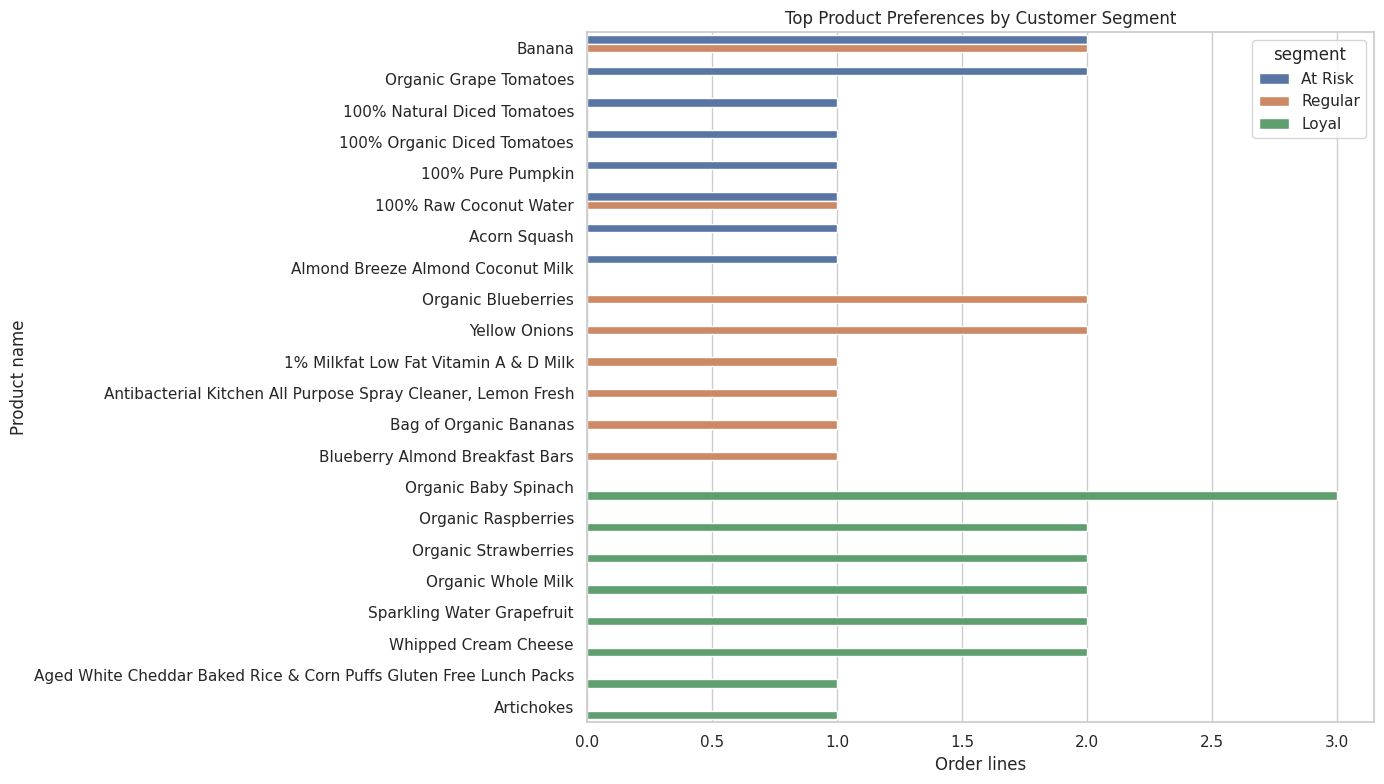

,segment,product_name,order_lines
0,At Risk,Banana,2
1,At Risk,Organic Grape Tomatoes,2
2,At Risk,100% Natural Diced Tomatoes,1
3,At Risk,100% Organic Diced Tomatoes,1
4,At Risk,100% Pure Pumpkin,1
5,At Risk,100% Raw Coconut Water,1
6,At Risk,Acorn Squash,1
7,At Risk,Almond Breeze Almond Coconut Milk,1
8,Regular,Banana,2
9,Regular,Organic Blueberries,2


In [33]:
segment_product_pref = (
    df.merge(rfm[["user_id", "segment"]], on="user_id", how="left")
    .groupby(["segment", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)

top_products_by_segment = (
    segment_product_pref.sort_values(
        ["segment", "order_lines", "product_name"],
        ascending=[True, False, True],
    )
    .groupby("segment", observed=False)
    .head(8)
    .reset_index(drop=True)
)

plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_products_by_segment,
    x="order_lines",
    y="product_name",
    hue="segment",
)
plt.title("Top Product Preferences by Customer Segment")
plt.xlabel("Order lines")
plt.ylabel("Product name")
plt.tight_layout()
plt.show()

display(top_products_by_segment)

### 3. Retention / Churn analysis

### 4. Basket value or repeat rate by product category

### 5. Customer lifetime value (CLV) trends